# Advanced Pandas for Real-World Analysis

Production-ready workflows demand **scalable, efficient and structured** data handling. This notebook covers:

1. Vectorisation vs Iteration
2. Efficient Filtering
3. Advanced GroupBy and Aggregations
4. Window Functions (Rolling, Expanding, Ranking)
5. Pivot Tables
6. Missing Data Strategies
7. Data Type Optimisation

In [14]:
import pandas as pd
import numpy as np
import time

np.random.seed(42)

In [15]:
# Sales dataset used throughout this notebook
n = 10_000
df = pd.DataFrame({
    'date':     pd.date_range('2023-01-01', periods=n, freq='h'),
    'region':   np.random.choice(['North', 'South', 'East', 'West'], n),
    'product':  np.random.choice(['Alpha', 'Beta', 'Gamma'], n),
    'channel':  np.random.choice(['Online', 'Retail', 'B2B'], n),
    'quantity': np.random.randint(1, 50, n),
    'price':    np.random.uniform(10, 500, n).round(2),
    'cost':     np.random.uniform(5, 250, n).round(2),
    'age':      np.random.randint(18, 70, n),
})
df['revenue'] = (df['quantity'] * df['price']).round(2)

# Introduce some missing values
df.loc[np.random.choice(df.index, 200), 'price'] = np.nan
df.loc[np.random.choice(df.index, 100), 'region'] = np.nan

print(df.shape)
df.head()

(10000, 9)


,date,region,product,channel,quantity,price,cost,age,revenue
0,2023-01-01 00:00:00,East,Gamma,Online,9,153.73,28.42,42,1383.57
1,2023-01-01 01:00:00,West,Gamma,Online,27,289.07,79.24,38,7804.89
2,2023-01-01 02:00:00,North,Gamma,B2B,41,491.73,61.56,36,20160.93
3,2023-01-01 03:00:00,East,Beta,Online,14,116.57,59.73,41,1631.98
4,2023-01-01 04:00:00,East,Gamma,Online,45,493.09,161.43,24,22189.05


## 1. Vectorisation vs Iteration

Python loops process rows one by one — interpreter overhead, slow. Vectorised operations use **C-optimised backends** on entire arrays: **10x–100x faster** on large datasets.

> Rule: if you reach for `.apply()` or a loop, stop and look for a vectorised alternative.

In [16]:
# Slow: row-by-row with .apply()
start = time.time()
df['margin_apply'] = df.apply(lambda row: row['price'] - row['cost']
                               if pd.notna(row['price']) else np.nan, axis=1)
print(f"apply():       {time.time() - start:.4f}s")

# Fast: vectorised column arithmetic
start = time.time()
df['margin_vec'] = df['price'] - df['cost']
print(f"vectorised:    {time.time() - start:.4f}s")

# Verify both produce identical results (ignoring NaNs)
equal = df['margin_apply'].equals(df['margin_vec'])
print(f"Results equal: {equal}")

apply():       0.0605s
vectorised:    0.0006s
Results equal: True


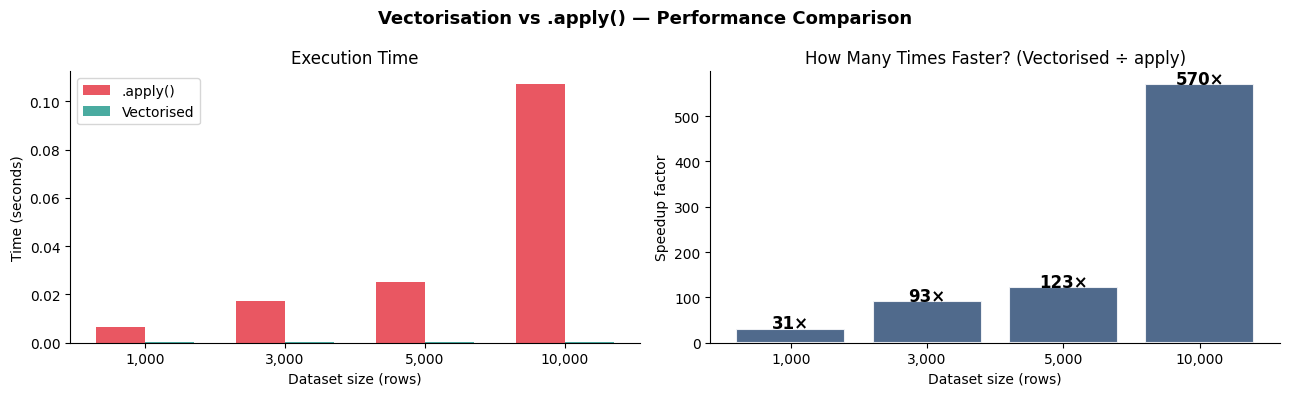

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Benchmark across increasing dataset sizes to show scaling behaviour
sizes       = [1_000, 3_000, 5_000, 10_000]
apply_times = []
vec_times   = []

for size in sizes:
    _df = df.head(size).copy()

    t0 = time.time()
    _df.apply(lambda row: row['price'] - row['cost']
              if pd.notna(row['price']) else np.nan, axis=1)
    apply_times.append(time.time() - t0)

    t0 = time.time()
    _df['price'] - _df['cost']
    vec_times.append(time.time() - t0)

speedups = [a / v for a, v in zip(apply_times, vec_times)]
labels   = [f'{s:,}' for s in sizes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Vectorisation vs .apply() — Performance Comparison',
             fontsize=13, fontweight='bold')

# Panel 1 — Absolute execution time
x, w = np.arange(len(sizes)), 0.35
b1 = axes[0].bar(x - w/2, apply_times, w, color='#e63946', alpha=0.85, label='.apply()')
b2 = axes[0].bar(x + w/2, vec_times,   w, color='#2a9d8f', alpha=0.85, label='Vectorised')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Dataset size (rows)')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Execution Time')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Speedup ratio
bars = axes[1].bar(labels, speedups, color='#3d5a80', edgecolor='white',
                   linewidth=1.5, alpha=0.9)
for bar, sp in zip(bars, speedups):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{sp:.0f}×', ha='center', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dataset size (rows)')
axes[1].set_ylabel('Speedup factor')
axes[1].set_title('How Many Times Faster? (Vectorised ÷ apply)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 2. Efficient Filtering

| Method | Use case |
|---|---|
| `&` / `\|` with masks | Multi-condition boolean indexing |
| `.query()` | Readable string expressions |
| `.isin()` | Categorical membership checks |
| `.between()` | Numeric range checks |

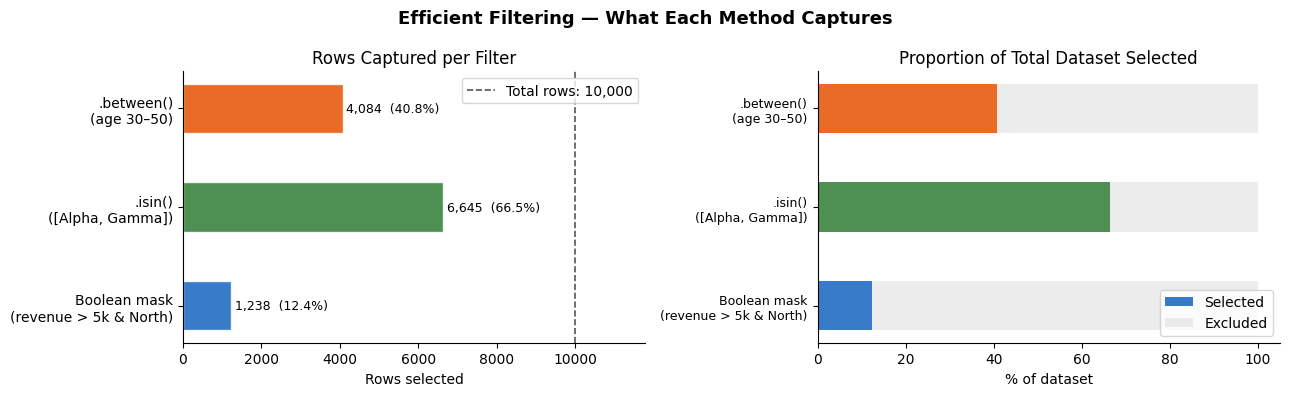

In [18]:
import matplotlib.pyplot as plt

total = len(df)
filter_data = {
    'Boolean mask\n(revenue > 5k & North)': mask.sum(),
    '.isin()\n([Alpha, Gamma])':             len(top_products),
    '.between()\n(age 30–50)':               len(mid_age),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Efficient Filtering — What Each Method Captures',
             fontsize=13, fontweight='bold')

colors = ['#1565C0', '#2E7D32', '#E65100']

# Panel 1 — Row count per filter with % annotation
bars = axes[0].barh(list(filter_data.keys()), list(filter_data.values()),
                    color=colors, alpha=0.85, edgecolor='white', height=0.5)
axes[0].axvline(total, color='#555', linestyle='--', linewidth=1.2,
                label=f'Total rows: {total:,}')
for bar, val in zip(bars, filter_data.values()):
    pct = val / total * 100
    axes[0].text(val + 80, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9)
axes[0].set_xlabel('Rows selected')
axes[0].set_title('Rows Captured per Filter')
axes[0].set_xlim(0, total * 1.18)
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Proportion of total (stacked to 100%)
selected = list(filter_data.values())
not_selected = [total - s for s in selected]
labels = list(filter_data.keys())
y = range(len(labels))

axes[1].barh(y, [s / total * 100 for s in selected],
             color=colors, alpha=0.85, label='Selected', height=0.5)
axes[1].barh(y, [ns / total * 100 for ns in not_selected],
             left=[s / total * 100 for s in selected],
             color='#e0e0e0', alpha=0.6, label='Excluded', height=0.5)
axes[1].set_yticks(list(y))
axes[1].set_yticklabels(labels, fontsize=9)
axes[1].set_xlabel('% of dataset')
axes[1].set_title('Proportion of Total Dataset Selected')
axes[1].legend(loc='lower right')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
# Multi-condition boolean indexing
mask = (df['revenue'] > 5000) & (df['region'] == 'North')
print(f"Boolean mask result: {mask.sum()} rows")

# .query() — cleaner and more readable
result_query = df.query("revenue > 5000 and region == 'North'")
print(f".query() result:     {len(result_query)} rows")

# .isin() — check membership in a set
top_products = df[df['product'].isin(['Alpha', 'Gamma'])]
print(f".isin() result:      {len(top_products)} rows")

# .between() — numeric range
mid_age = df[df['age'].between(30, 50)]
print(f".between() result:   {len(mid_age)} rows")

Boolean mask result: 1238 rows
.query() result:     1238 rows
.isin() result:      6645 rows
.between() result:   4084 rows


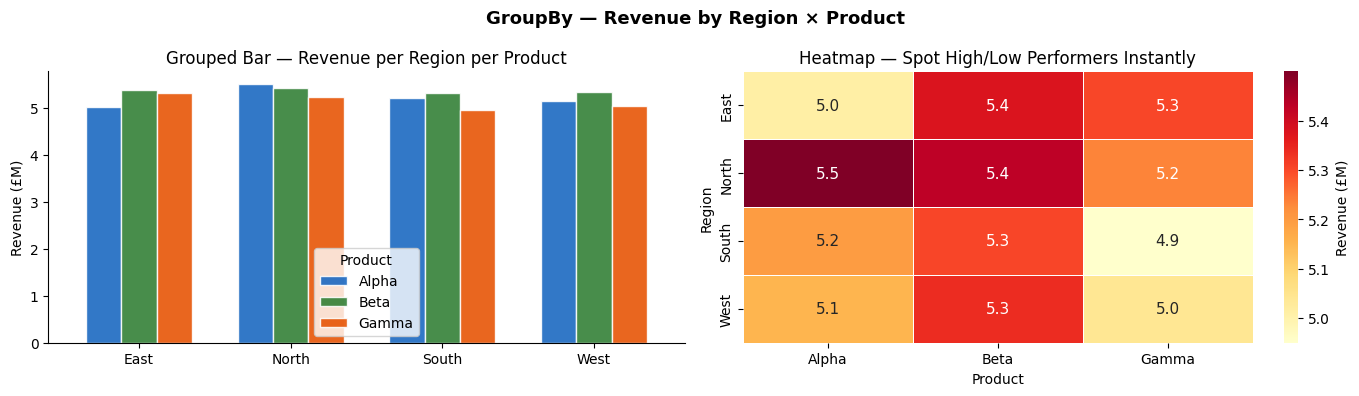

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot_rev = summary.pivot(index='region', columns='product',
                          values='total_revenue') / 1e6  # £M

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('GroupBy — Revenue by Region × Product',
             fontsize=13, fontweight='bold')

# Panel 1 — Grouped bar chart
pivot_rev.plot(kind='bar', ax=axes[0],
               color=['#1565C0', '#2E7D32', '#E65100'],
               edgecolor='white', alpha=0.88, width=0.7)
axes[0].set_title('Grouped Bar — Revenue per Region per Product')
axes[0].set_ylabel('Revenue (£M)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Product')
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Heatmap: instant pattern detection
sns.heatmap(pivot_rev, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.6, ax=axes[1],
            cbar_kws={'label': 'Revenue (£M)'},
            annot_kws={'fontsize': 11})
axes[1].set_title('Heatmap — Spot High/Low Performers Instantly')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()

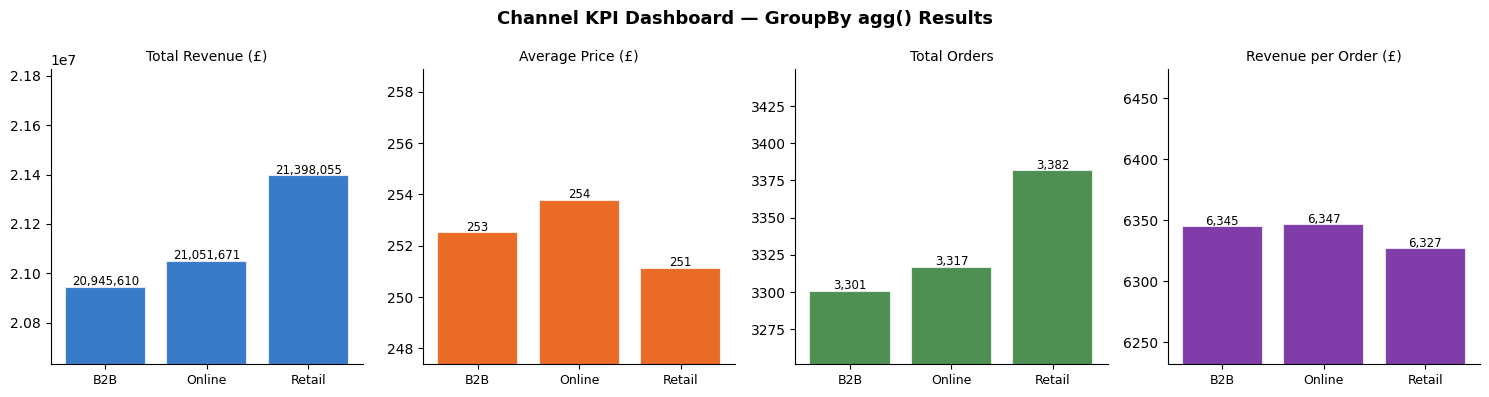

In [21]:
import matplotlib.pyplot as plt

metrics = [
    ('total_revenue',      'Total Revenue (£)',    '#1565C0'),
    ('avg_price',          'Average Price (£)',     '#E65100'),
    ('total_orders',       'Total Orders',          '#2E7D32'),
    ('conversion_proxy',   'Revenue per Order (£)', '#6A1B9A'),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('Channel KPI Dashboard — GroupBy agg() Results',
             fontsize=13, fontweight='bold')

for ax, (col, title, color) in zip(axes, metrics):
    vals  = kpi[col]
    ymin  = vals.min() * 0.985
    ymax  = vals.max() * 1.02

    bars = ax.bar(kpi.index, vals, color=color, alpha=0.85,
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (ymax - ymin) * 0.005,
                f'{val:,.0f}', ha='center', fontsize=8.5)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='x', labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Advanced GroupBy and Aggregations

GroupBy is **analytical architecture**. Multi-column grouping reveals patterns that flat aggregation conceals.

In [22]:
# Multi-column grouping: Region × Product × Channel
summary = (
    df.groupby(['region', 'product'])
      .agg(
          total_revenue=('revenue', 'sum'),
          avg_margin=('margin_vec', 'mean'),
          customer_count=('quantity', 'count'),
      )
      .round(2)
      .reset_index()
)
print("Multi-level aggregation:")
summary.head(10)

Multi-level aggregation:


,region,product,total_revenue,avg_margin,customer_count
0,East,Alpha,5010306.00,128.25,799
1,East,Beta,5377748.59,130.14,817
2,East,Gamma,5303979.53,131.15,836
3,North,Alpha,5499792.79,127.01,867
4,North,Beta,5427387.80,126.32,831
5,North,Gamma,5235551.02,123.62,812
6,South,Alpha,5197538.41,123.68,819
7,South,Beta,5305088.43,127.99,828
8,South,Gamma,4949887.05,119.64,810
9,West,Alpha,5149866.57,114.99,842


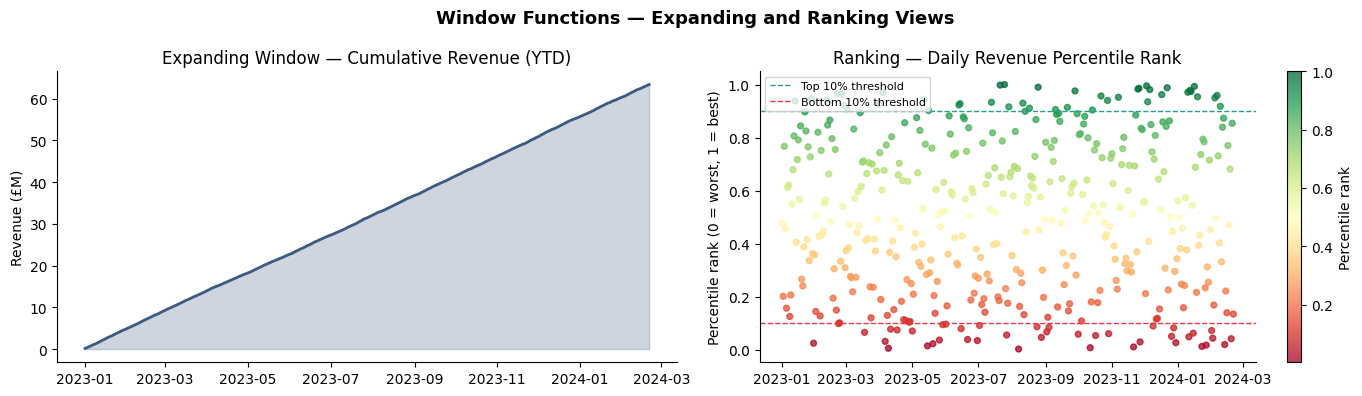

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Window Functions — Expanding and Ranking Views',
             fontsize=13, fontweight='bold')

# Panel 1 — Expanding: cumulative revenue with fill
axes[0].fill_between(daily['date'],
                     daily['cumulative_revenue'] / 1e6,
                     alpha=0.25, color='#3d5a80')
axes[0].plot(daily['date'],
             daily['cumulative_revenue'] / 1e6,
             color='#3d5a80', linewidth=2)
axes[0].set_title('Expanding Window — Cumulative Revenue (YTD)')
axes[0].set_ylabel('Revenue (£M)')
axes[0].set_xlabel('')
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Percentile rank scatter (green = top, red = bottom days)
sc = axes[1].scatter(daily['date'], daily['pct_rank'],
                     c=daily['pct_rank'], cmap='RdYlGn',
                     s=18, alpha=0.75)
plt.colorbar(sc, ax=axes[1], label='Percentile rank')
axes[1].axhline(0.9, color='#2a9d8f', linestyle='--',
                linewidth=1, label='Top 10% threshold')
axes[1].axhline(0.1, color='#e63946', linestyle='--',
                linewidth=1, label='Bottom 10% threshold')
axes[1].set_title('Ranking — Daily Revenue Percentile Rank')
axes[1].set_ylabel('Percentile rank (0 = worst, 1 = best)')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
# Custom domain-specific aggregations: KPI metrics
def revenue_per_unit(s):
    return s.sum() / len(s)

kpi = (
    df.groupby('channel')
      .agg(
          total_revenue=('revenue', 'sum'),
          avg_price=('price', 'mean'),
          conversion_proxy=('revenue', revenue_per_unit),
          total_orders=('quantity', 'count'),
      )
      .round(2)
)
print("Channel KPIs:")
kpi

Channel KPIs:


,total_revenue,avg_price,conversion_proxy,total_orders
channel,,,,
B2B,20945610.23,252.52,6345.23,3301
Online,21051671.36,253.80,6346.60,3317
Retail,21398055.20,251.15,6327.04,3382


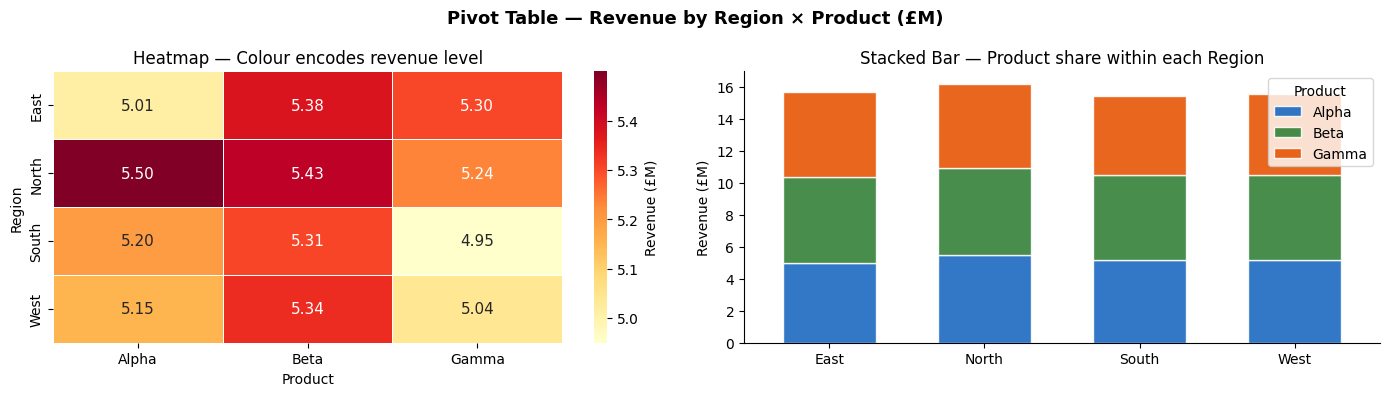

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the 'Total' margins row/col for the heatmap
pivot_hm = (pivot
            .drop('Total', axis=0)
            .drop('Total', axis=1)
            / 1e6)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Pivot Table — Revenue by Region × Product (£M)',
             fontsize=13, fontweight='bold')

# Panel 1 — Heatmap with annotated values
sns.heatmap(pivot_hm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.6, ax=axes[0],
            cbar_kws={'label': 'Revenue (£M)'},
            annot_kws={'fontsize': 11})
axes[0].set_title('Heatmap — Colour encodes revenue level')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Region')

# Panel 2 — Stacked bar to show product share within each region
pivot_hm.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#1565C0', '#2E7D32', '#E65100'],
              edgecolor='white', alpha=0.88, width=0.6)
axes[1].set_title('Stacked Bar — Product share within each Region')
axes[1].set_ylabel('Revenue (£M)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Product')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Window Functions

Window functions compute values **across a moving subset of rows without collapsing the dataset**.

| Type | What it does |
|---|---|
| **Rolling** | Sliding window (e.g. 7-day moving average) |
| **Expanding** | Accumulate from start to current row |
| **Ranking** | Assign relative positions |

In [26]:
# Daily aggregation for time-series window analysis
daily = (
    df.set_index('date')
      .resample('D')['revenue']
      .sum()
      .reset_index()
      .rename(columns={'revenue': 'daily_revenue'})
)

# Rolling: 7-day moving average smooths daily volatility
daily['rolling_7d'] = daily['daily_revenue'].rolling(window=7).mean()

# Expanding: cumulative revenue year-to-date
daily['cumulative_revenue'] = daily['daily_revenue'].expanding().sum()

# Ranking: percentile rank of each day
daily['pct_rank'] = daily['daily_revenue'].rank(pct=True).round(3)

print("Window function output (last 10 days):")
daily.tail(10)

Window function output (last 10 days):


,date,daily_revenue,rolling_7d,cumulative_revenue,pct_rank
407,2024-02-12,181053.47,171107.671429,62148827.88,0.873
408,2024-02-13,98279.32,157003.584286,62247107.20,0.019
409,2024-02-14,131845.12,151863.228571,62378952.32,0.221
410,2024-02-15,123378.10,148636.180000,62502330.42,0.139
411,2024-02-16,170873.11,146305.521429,62673203.53,0.770
412,2024-02-17,149833.25,147565.008571,62823036.78,0.470
413,2024-02-18,163949.90,145601.752857,62986986.68,0.681
414,2024-02-19,106814.54,134996.191429,63093801.22,0.041
415,2024-02-20,178298.32,146427.477143,63272099.54,0.854
416,2024-02-21,123237.25,145197.781429,63395336.79,0.134


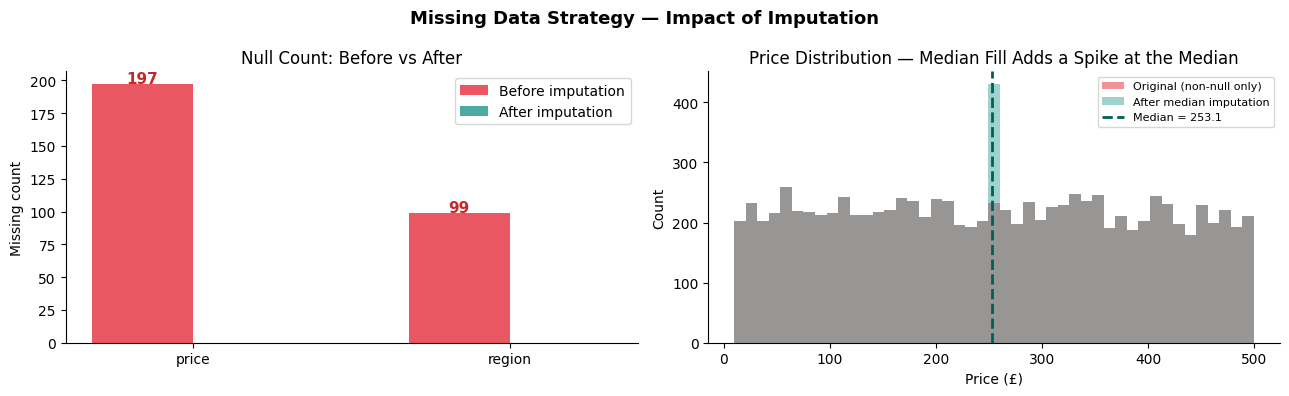

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Missing Data Strategy — Impact of Imputation',
             fontsize=13, fontweight='bold')

# Panel 1 — Missing count before vs after per column
miss_cols    = ['price', 'region']
miss_before  = [df[c].isnull().sum()       for c in miss_cols]
miss_after   = [df_clean[c].isnull().sum() for c in miss_cols]

x, w = [0, 1], 0.32
b1 = axes[0].bar([xi - w/2 for xi in x], miss_before, w,
                 color='#e63946', alpha=0.85, label='Before imputation')
b2 = axes[0].bar([xi + w/2 for xi in x], miss_after, w,
                 color='#2a9d8f', alpha=0.85, label='After imputation')
axes[0].set_xticks(x)
axes[0].set_xticklabels(miss_cols)
axes[0].set_ylabel('Missing count')
axes[0].set_title('Null Count: Before vs After')
axes[0].legend()
for bar, val in zip(b1.patches, miss_before):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.8, str(val),
                 ha='center', fontsize=11, fontweight='bold', color='#c62828')
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Price distribution: original non-null vs after imputation
med = df['price'].median()
axes[1].hist(df['price'].dropna(), bins=45,
             color='#e63946', alpha=0.55, label='Original (non-null only)')
axes[1].hist(df_clean['price'], bins=45,
             color='#2a9d8f', alpha=0.45, label='After median imputation')
axes[1].axvline(med, color='#005f56', linewidth=2, linestyle='--',
                label=f'Median = {med:.1f}')
axes[1].set_title('Price Distribution — Median Fill Adds a Spike at the Median')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

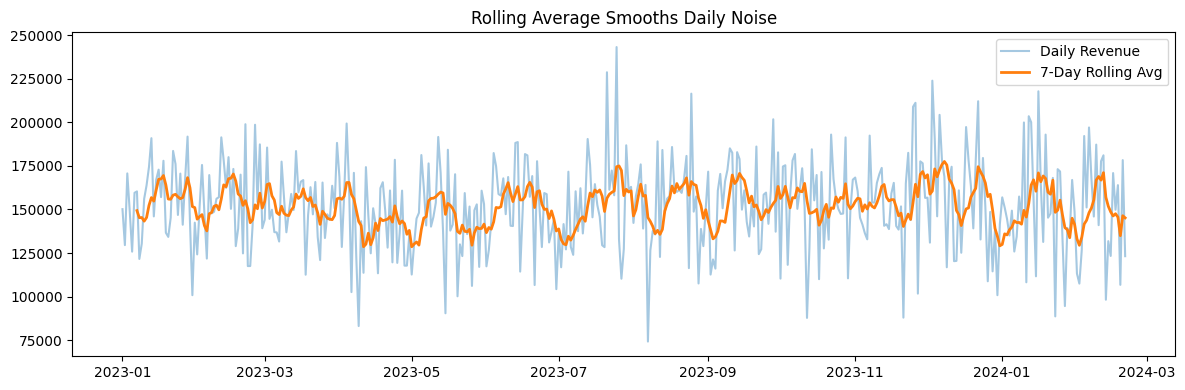

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily['date'], daily['daily_revenue'], alpha=0.4, label='Daily Revenue')
ax.plot(daily['date'], daily['rolling_7d'], linewidth=2, label='7-Day Rolling Avg')
ax.set_title('Rolling Average Smooths Daily Noise')
ax.legend()
plt.tight_layout()
plt.show()

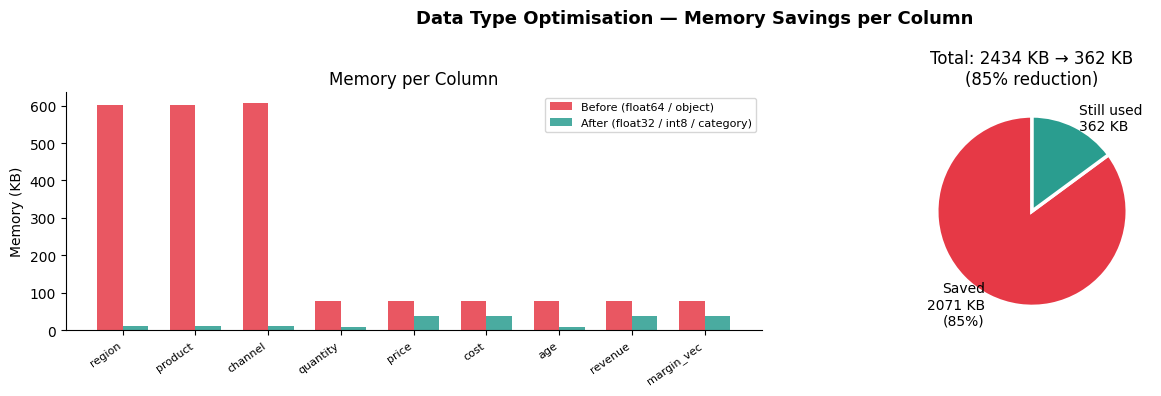

In [29]:
import matplotlib.pyplot as plt

tracked = ['region', 'product', 'channel', 'quantity', 'price', 'cost', 'age', 'revenue', 'margin_vec']

mem_before_kb = {c: df_clean[c].memory_usage(deep=True) / 1024 for c in tracked}
mem_after_kb  = {c: df_opt[c].memory_usage(deep=True)   / 1024 for c in tracked}

before_vals = list(mem_before_kb.values())
after_vals  = list(mem_after_kb.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Data Type Optimisation — Memory Savings per Column',
             fontsize=13, fontweight='bold')

# Panel 1 — Per-column grouped bar
x, w = range(len(tracked)), 0.35
axes[0].bar([xi - w/2 for xi in x], before_vals, w,
            color='#e63946', alpha=0.85, label='Before (float64 / object)')
axes[0].bar([xi + w/2 for xi in x], after_vals,  w,
            color='#2a9d8f', alpha=0.85, label='After (float32 / int8 / category)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(tracked, rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('Memory (KB)')
axes[0].set_title('Memory per Column')
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Pie: total saved vs total used
total_before = df_clean.memory_usage(deep=True).sum() / 1024
total_after  = df_opt.memory_usage(deep=True).sum()   / 1024
saved        = total_before - total_after

wedge_kw = {'edgecolor': 'white', 'linewidth': 2.5}
axes[1].pie(
    [saved, total_after],
    labels=[f'Saved\n{saved:.0f} KB\n({saved/total_before*100:.0f}%)',
            f'Still used\n{total_after:.0f} KB'],
    colors=['#e63946', '#2a9d8f'],
    startangle=90,
    wedgeprops=wedge_kw,
    textprops={'fontsize': 10},
)
axes[1].set_title(f'Total: {total_before:.0f} KB → {total_after:.0f} KB\n'
                  f'({(1-total_after/total_before)*100:.0f}% reduction)')

plt.tight_layout()
plt.show()

## 5. Pivot Tables

Pivot tables transform raw data into **structured business reports** — bridging exploratory analysis and stakeholder reporting.

In [30]:
pivot = pd.pivot_table(
    df,
    values='revenue',
    index='region',
    columns='product',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
).round(0)

print("Revenue by Region × Product:")
pivot

Revenue by Region × Product:


product,Alpha,Beta,Gamma,Total
region,,,,
East,5010306.0,5377749.0,5303980.0,15692034.0
North,5499793.0,5427388.0,5235551.0,16162732.0
South,5197538.0,5305088.0,4949887.0,15452514.0
West,5149867.0,5337738.0,5041808.0,15529413.0
Total,20857504.0,21447963.0,20531226.0,62836693.0


## 6. Missing Data Strategies

Missing data is a **business risk**, not just a technical issue.

**Types of missingness:**
- **MCAR** (Missing Completely At Random) — safe to delete rows
- **MAR** (Missing At Random) — depends on observed variables; impute
- **MNAR** (Missing Not At Random) — requires domain knowledge

**Imputation methods:** delete rows, mean/median, forward-fill, model-based

In [31]:
print("Missing value audit:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()} / {df.size} ({df.isnull().mean().mean()*100:.2f}%)")

Missing value audit:
date              0
region           99
product           0
channel           0
quantity          0
price           197
cost              0
age               0
revenue           0
margin_apply    197
margin_vec      197
dtype: int64

Total missing: 690 / 110000 (0.63%)


In [32]:
df_clean = df.copy()

# Numeric: median imputation (robust to outliers)
df_clean['price'] = df_clean['price'].fillna(df_clean['price'].median())

# Categorical: mode imputation
df_clean['region'] = df_clean['region'].fillna(df_clean['region'].mode()[0])

print("Remaining missing after imputation:")
print(df_clean[['price', 'region']].isnull().sum())

Remaining missing after imputation:
price     0
region    0
dtype: int64


## 7. Data Type Optimisation

By default Pandas assigns types that consume more memory than necessary. Optimising can yield:
- **Up to 70% memory reduction**
- **Up to 5x faster operations** on large datasets

In [33]:
mem_before = df_clean.memory_usage(deep=True).sum() / 1024**2
print(f"Memory before optimisation: {mem_before:.2f} MB")
print(df_clean.dtypes)

df_opt = df_clean.copy()

# String columns with few unique values → category
for col in ['region', 'product', 'channel']:
    df_opt[col] = df_opt[col].astype('category')

# Downcast integers
df_opt['quantity'] = pd.to_numeric(df_opt['quantity'], downcast='integer')
df_opt['age']      = pd.to_numeric(df_opt['age'],      downcast='integer')

# Use float32 where full float64 precision is unnecessary
for col in ['price', 'cost', 'revenue', 'margin_vec']:
    df_opt[col] = df_opt[col].astype('float32')

mem_after = df_opt.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory after optimisation:  {mem_after:.2f} MB")
print(f"Reduction: {(1 - mem_after/mem_before)*100:.1f}%")

Memory before optimisation: 2.38 MB
date            datetime64[ns]
region                  object
product                 object
channel                 object
quantity                 int64
price                  float64
cost                   float64
age                      int64
revenue                float64
margin_apply           float64
margin_vec             float64
dtype: object

Memory after optimisation:  0.35 MB
Reduction: 85.1%


## Dataset Health Checks

Before modelling, always run three checks: **Distribution**, **Outlier detection**, **Skewness**.

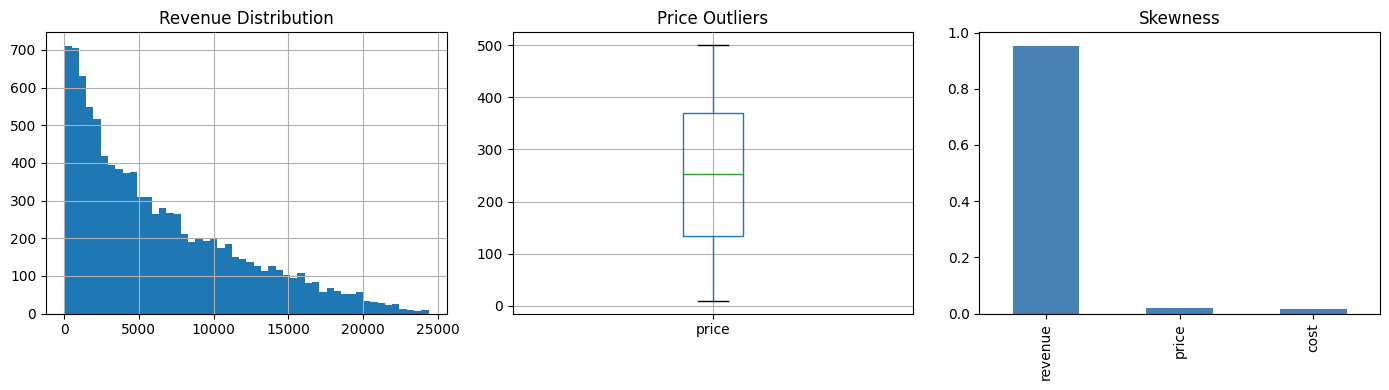


Skewness values:
revenue    0.953
price      0.019
cost       0.015
dtype: float64


In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribution check
df_clean['revenue'].hist(bins=50, ax=axes[0])
axes[0].set_title('Revenue Distribution')

# Outlier check via boxplot
df_clean.boxplot(column='price', ax=axes[1])
axes[1].set_title('Price Outliers')

# Skewness
skew = df_clean[['revenue', 'price', 'cost']].skew()
skew.plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].axhline(0, color='red', linewidth=0.8)
axes[2].set_title('Skewness')

plt.tight_layout()
plt.show()

print("\nSkewness values:")
print(skew.round(3))

## Key Takeaways

- **Always prefer vectorised operations** over `.apply()` or loops.
- Use `.query()`, `.isin()`, `.between()` for readable and fast filtering.
- GroupBy is analytical architecture — design aggregations to answer business questions.
- Window functions convert raw chronological data into actionable signals.
- Never skip **dataset health checks** before feature engineering.